In [1]:
import os
import pandas as pd
import requests

In [2]:
import os

base = r"C:\Users\sofiya chavarekar\OneDrive\Assignment- Module 1\PROJECT(AI-based drug target identification for SDH-related rare disorders)\Data"

raw_folder = os.path.join(base, "Ligands", "Raw")
properties_folder = os.path.join(base, "Ligands", "Properties")

os.makedirs(raw_folder, exist_ok=True)
os.makedirs(properties_folder, exist_ok=True)

print("Raw Folder:", raw_folder)
print("Properties Folder:", properties_folder)

Raw Folder: C:\Users\sofiya chavarekar\OneDrive\Assignment- Module 1\PROJECT(AI-based drug target identification for SDH-related rare disorders)\Data\Ligands\Raw
Properties Folder: C:\Users\sofiya chavarekar\OneDrive\Assignment- Module 1\PROJECT(AI-based drug target identification for SDH-related rare disorders)\Data\Ligands\Properties


In [3]:
import requests
import os

url = "https://raw.githubusercontent.com/rdkit/rdkit/master/Docs/Book/data/solubility.test.sdf"

output_file = os.path.join(raw_folder, "drug_like_molecules.sdf")

response = requests.get(url)

with open(output_file, "wb") as f:
    f.write(response.content)

print("Ligand dataset downloaded successfully!")
print(output_file)

Ligand dataset downloaded successfully!
C:\Users\sofiya chavarekar\OneDrive\Assignment- Module 1\PROJECT(AI-based drug target identification for SDH-related rare disorders)\Data\Ligands\Raw\drug_like_molecules.sdf


In [4]:
import os

files = os.listdir(raw_folder)

print("Files in Raw folder:")

for file in files:
    print(file)

Files in Raw folder:
drug_like_molecules.sdf


In [5]:
size = os.path.getsize(output_file)

print(f"Dataset Size: {size/1024:.2f} KB")

Dataset Size: 239.98 KB


In [6]:
from rdkit import Chem
from rdkit.Chem import Descriptors

print("RDKit installed successfully!")

RDKit installed successfully!


In [7]:
from rdkit import Chem
import os

sdf_file = os.path.join(raw_folder, "drug_like_molecules.sdf")

supplier = Chem.SDMolSupplier(sdf_file)

molecules = [mol for mol in supplier if mol is not None]

print("Total molecules:", len(molecules))

Total molecules: 257


In [17]:
from rdkit import Chem
from rdkit.Chem import Descriptors

data = []

for i, mol in enumerate(molecules):

    data.append({
        "Ligand_ID": i + 1,
        "SMILES": Chem.MolToSmiles(mol),      # <-- Add this line
        "Molecular_Weight": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "H_Bond_Donors": Descriptors.NumHDonors(mol),
        "H_Bond_Acceptors": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "Rotatable_Bonds": Descriptors.NumRotatableBonds(mol)
    })

df = pd.DataFrame(data)

print(df.head())

   Ligand_ID       SMILES  Molecular_Weight    LogP  H_Bond_Donors  \
0          1     CCC(C)CC            86.178  2.4425              0   
1          2  CC(C)CC(C)C           100.205  2.6885              0   
2          3       C=CCCC            70.135  1.9725              0   
3          4    C1=CCCCC1            82.146  2.1166              0   
4          5      C=CCC=C            68.119  1.7485              0   

   H_Bond_Acceptors  TPSA  Rotatable_Bonds  
0                 0   0.0                2  
1                 0   0.0                2  
2                 0   0.0                2  
3                 0   0.0                0  
4                 0   0.0                2  


In [18]:
print(df.describe())

        Ligand_ID  Molecular_Weight        LogP  H_Bond_Donors  \
count  257.000000        257.000000  257.000000     257.000000   
mean   129.000000        202.174767    2.316278       0.867704   
std     74.333707         96.407787    1.782007       1.217551   
min      1.000000         62.137000   -8.424200       0.000000   
25%     65.000000        126.115000    1.366020       0.000000   
50%    129.000000        180.163000    2.181400       1.000000   
75%    193.000000        265.914000    3.211700       1.000000   
max    257.000000        585.608000    8.580800      13.000000   

       H_Bond_Acceptors        TPSA  Rotatable_Bonds  
count        257.000000  257.000000       257.000000  
mean           2.019455   36.363463         2.050584  
std            2.004782   36.828463         2.127152  
min            0.000000    0.000000         0.000000  
25%            1.000000    9.230000         0.000000  
50%            2.000000   27.690000         2.000000  
75%            3.000

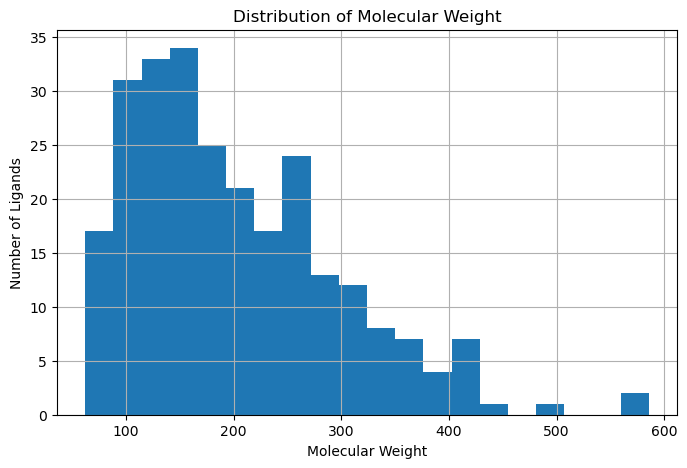

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Molecular_Weight"], bins=20)
plt.title("Distribution of Molecular Weight")
plt.xlabel("Molecular Weight")
plt.ylabel("Number of Ligands")
plt.grid(True)
plt.show()

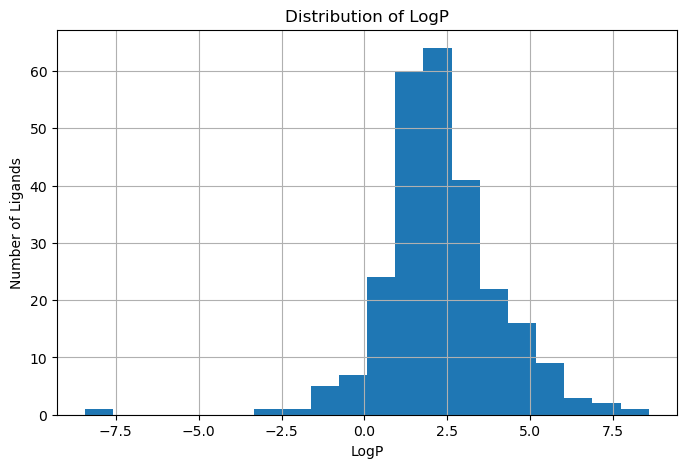

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["LogP"], bins=20)
plt.title("Distribution of LogP")
plt.xlabel("LogP")
plt.ylabel("Number of Ligands")
plt.grid(True)
plt.show()

In [20]:
filtered_df = df[
    (df["Molecular_Weight"] <= 500) &
    (df["LogP"] <= 5) &
    (df["H_Bond_Donors"] <= 5) &
    (df["H_Bond_Acceptors"] <= 10)
].copy()

print("Original molecules :", len(df))
print("Drug-like molecules :", len(filtered_df))

Original molecules : 257
Drug-like molecules : 237


In [21]:
filtered_file = os.path.join(
    properties_folder,
    "Filtered_Ligands.xlsx"
)

filtered_df.to_excel(filtered_file, index=False)

print("Filtered ligands saved successfully!")
print(filtered_file)

Filtered ligands saved successfully!
C:\Users\sofiya chavarekar\OneDrive\Assignment- Module 1\PROJECT(AI-based drug target identification for SDH-related rare disorders)\Data\Ligands\Properties\Filtered_Ligands.xlsx


In [14]:
from rdkit import Chem
from rdkit.Chem import Descriptors

data = []

for i, mol in enumerate(molecules):

    smiles = Chem.MolToSmiles(mol)

    data.append({
        "Ligand_ID": i + 1,
        "SMILES": smiles,
        "Molecular_Weight": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "H_Bond_Donors": Descriptors.NumHDonors(mol),
        "H_Bond_Acceptors": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "Rotatable_Bonds": Descriptors.NumRotatableBonds(mol)
    })

df = pd.DataFrame(data)

df.head()

,Ligand_ID,SMILES,Molecular_Weight,LogP,H_Bond_Donors,H_Bond_Acceptors,TPSA,Rotatable_Bonds
0,1,CCC(C)CC,86.178,2.4425,0,0,0.0,2
1,2,CC(C)CC(C)C,100.205,2.6885,0,0,0.0,2
2,3,C=CCCC,70.135,1.9725,0,0,0.0,2
3,4,C1=CCCCC1,82.146,2.1166,0,0,0.0,0
4,5,C=CCC=C,68.119,1.7485,0,0,0.0,2


In [22]:
print(df.columns)
df.head()

Index(['Ligand_ID', 'SMILES', 'Molecular_Weight', 'LogP', 'H_Bond_Donors',
       'H_Bond_Acceptors', 'TPSA', 'Rotatable_Bonds'],
      dtype='object')


,Ligand_ID,SMILES,Molecular_Weight,LogP,H_Bond_Donors,H_Bond_Acceptors,TPSA,Rotatable_Bonds
0,1,CCC(C)CC,86.178,2.4425,0,0,0.0,2
1,2,CC(C)CC(C)C,100.205,2.6885,0,0,0.0,2
2,3,C=CCCC,70.135,1.9725,0,0,0.0,2
3,4,C1=CCCCC1,82.146,2.1166,0,0,0.0,0
4,5,C=CCC=C,68.119,1.7485,0,0,0.0,2


In [23]:
print(filtered_df.columns)

Index(['Ligand_ID', 'SMILES', 'Molecular_Weight', 'LogP', 'H_Bond_Donors',
       'H_Bond_Acceptors', 'TPSA', 'Rotatable_Bonds'],
      dtype='object')
